다음 경로가 실제 프로젝트를 가리키는지 확인합니다.


In [1]:
from pathlib import Path
import sys

# ---- 프로젝트 루트 찾기 (노트북을 어느 폴더에서 열어도 동작한다) ----
# 현재 폴더에서 시작해 위로 한 단계씩 올라가며 data 폴더가 있는 곳을 찾는다.
PROJECT_ROOT = Path.cwd().resolve()

while not (PROJECT_ROOT / "data").is_dir():
    # 최상위(C:\)까지 올라왔는데도 못 찾으면 멈춘다. 이 검사가 없으면 무한 루프가 된다.
    if PROJECT_ROOT == PROJECT_ROOT.parent:
        raise FileNotFoundError("data 폴더를 찾지 못했습니다.")
    PROJECT_ROOT = PROJECT_ROOT.parent

# course_utils 를 import 할 수 있도록 프로젝트 루트를 검색 경로에 넣는다.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data" / "raw"

print("프로젝트 루트:", PROJECT_ROOT)
print("데이터 폴더:", DATA_DIR, "| 존재:", DATA_DIR.exists())


프로젝트 루트: C:\dev\llm-data-analysis-course
데이터 폴더: C:\dev\llm-data-analysis-course\data\raw | 존재: True


In [2]:
from course_utils.paths import get_project_root, get_data_dir

print("프로젝트 루트 :", get_project_root())
print("데이터 폴더:", get_data_dir())

프로젝트 루트 : C:\dev\llm-data-analysis-course
데이터 폴더: C:\dev\llm-data-analysis-course\data


In [3]:
PROJECT_ROOT = get_project_root()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"

# 결과를 저장할 폴더가 없으면 만들어 둔다.
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

print("원본 데이터 :", RAW_DIR)
print("정제 데이터 :", PROCESSED_DIR)
print("리포트     :", REPORT_DIR)


원본 데이터 : C:\dev\llm-data-analysis-course\data\raw
정제 데이터 : C:\dev\llm-data-analysis-course\data\processed
리포트     : C:\dev\llm-data-analysis-course\reports


## 1. 원본 데이터 불러오기

`data/raw` 폴더의 CSV 4개를 각각 DataFrame 으로 읽어 들입니다.
CSV 가 `utf-8-sig` 로 저장되어 있으므로 인코딩을 명시합니다.

In [4]:
import pandas as pd

customers   = pd.read_csv(RAW_DIR / "customers.csv",   encoding="utf-8-sig")
products    = pd.read_csv(RAW_DIR / "products.csv",    encoding="utf-8-sig")
orders      = pd.read_csv(RAW_DIR / "orders.csv",      encoding="utf-8-sig")
order_items = pd.read_csv(RAW_DIR / "order_items.csv", encoding="utf-8-sig")

for name, df in [("customers", customers), ("products", products),
                 ("orders", orders), ("order_items", order_items)]:
    print(f"{name:12s} {df.shape[0]:5d} 행 x {df.shape[1]} 열   {list(df.columns)}")


customers      150 행 x 6 열   ['customer_id', 'name', 'gender', 'age', 'city', 'signup_date']
products       100 행 x 4 열   ['product_id', 'product_name', 'category', 'price']
orders         300 행 x 5 열   ['order_id', 'customer_id', 'order_date', 'payment_method', 'order_status']
order_items    764 행 x 5 열   ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price']


In [5]:
print(customers.info())
print(products.info())
print(orders.info())
print(order_items.info())

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  150 non-null    int64
 1   name         150 non-null    str  
 2   gender       150 non-null    str  
 3   age          150 non-null    int64
 4   city         150 non-null    str  
 5   signup_date  150 non-null    str  
dtypes: int64(2), str(4)
memory usage: 7.2 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   product_id    100 non-null    int64
 1   product_name  100 non-null    str  
 2   category      100 non-null    str  
 3   price         100 non-null    int64
dtypes: int64(2), str(2)
memory usage: 3.3 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------

성공기준

4개 DataFrame 모두 정상 생성되어야 합니다.

In [6]:
print(customers.shape)
print(products.shape)
print(orders.shape)
print(order_items.shape)

(150, 6)
(100, 4)
(300, 5)
(764, 5)


In [7]:
raw_data = {
    "customers": customers,
    "products": products,
    "orders": orders,
    "order_items": order_items,
}

for name, df in raw_data.items():
    print(name)
    print("shape:", df.shape)
    print("missing:", int(df.isna().sum().sum()))
    print("duplicated rows:", int(df.duplicated().sum()))
    print()

customers
shape: (150, 6)
missing: 0
duplicated rows: 0

products
shape: (100, 4)
missing: 0
duplicated rows: 0

orders
shape: (300, 5)
missing: 0
duplicated rows: 0

order_items
shape: (764, 5)
missing: 0
duplicated rows: 0



STEP 4. 원본을 복사해 전처리용 DataFrame 만들기


In [8]:
customers_clean = customers.copy()
products_clean = products.copy()
orders_clean = orders.copy()
order_items_clean = order_items.copy



STEP 5. 문자열 공백과 빈 문자열 점검

In [9]:

customers_clean["name"] = customers_clean["name"].where(
    customers_clean["name"].isna(),
    customers_clean["name"].astype(str).str.strip(),
)

customers_clean["name"].head()

0    김수민
1    김정호
2    이경수
3    조영호
4    이예원
Name: name, dtype: str

In [12]:
import numpy as np

# 위 코드에 대한 예시 코드

# 새로운 데이터 프레임 만들기 => 리스트 + 딕셔내리

df = pd.DataFrame({
    'name' : ['홍길동', '이영희', np.nan, '박철수']
})

print("\n---[처리전]---")


print(df["name"].to_list())


---[처리전]---
['홍길동', '이영희', nan, '박철수']


In [13]:
# 기존 공백 제거 코드 실행

df["name"] = df["name"].where(
    df["name"].isna(),
   df["name"].astype(str).str.strip(),
)

print("\n---[처리후]---")


print(df["name"].to_list())


---[처리후]---
['홍길동', '이영희', nan, '박철수']


In [17]:
# 검증코드

print(df["name"].str.startswith(' ') | df["name"].str.endswith(' '))

0    False
1    False
2    False
3    False
Name: name, dtype: bool


In [23]:
cols = customers_clean.columns.to_list();
for col in cols:
    if customers_clean[col].dtype == "str":
        print(customers_clean[col].dtype)


str
str
str
str


In [ ]:
customers_clean["name"] = customers_clean["name"].replace(
    "",
    pd.NA,
)

In [26]:
print("" == " ")

False


In [27]:
customers_clean.isna().sum()

customer_id    0
name           0
gender         0
age            0
city           0
signup_date    0
dtype: int64

In [28]:
df.isna().sum()

name    1
dtype: int64

In [25]:
print("" == " ".strip())

True


## 2. 데이터 상태 점검

정제하기 전에 결측치와 중복이 얼마나 있는지 먼저 셉니다.
숫자를 확인한 뒤에 무엇을 고칠지 정하는 순서입니다.

In [ ]:
def check(name, df, key):
    """결측치와 키 중복 개수를 한 줄로 요약한다."""
    na_total = int(df.isna().sum().sum())
    dup = int(df.duplicated(subset=[key]).sum())
    print(f"[{name}] 결측치 {na_total}개 / {key} 중복 {dup}건")


check("customers",   customers,   "customer_id")
check("products",    products,    "product_id")
check("orders",      orders,      "order_id")
check("order_items", order_items, "order_item_id")

print()
print("주문 상태 분포")
print(orders["order_status"].value_counts(dropna=False))


[customers] 결측치 0개 / customer_id 중복 0건
[products] 결측치 0개 / product_id 중복 0건
[orders] 결측치 0개 / order_id 중복 0건
[order_items] 결측치 0개 / order_item_id 중복 0건

주문 상태 분포
order_status
completed    184
cancelled     64
refunded      52
Name: count, dtype: int64


## 3. 정제하기

원본은 그대로 두고 복사본(`_clean`)을 만들어 작업합니다.
원본을 덮어쓰면 잘못됐을 때 되돌릴 수 없습니다.

- 키가 중복된 행 제거
- `order_date` 를 날짜 타입으로 변환 (변환 실패는 `NaT` 로 표시)

In [ ]:
customers_clean   = customers.drop_duplicates(subset=["customer_id"]).copy()
products_clean    = products.drop_duplicates(subset=["product_id"]).copy()
orders_clean      = orders.drop_duplicates(subset=["order_id"]).copy()
order_items_clean = order_items.drop_duplicates(subset=["order_item_id"]).copy()

# 문자열로 읽힌 날짜를 datetime 으로 바꾼다. 잘못된 날짜는 NaT 가 된다.
orders_clean["order_date"] = pd.to_datetime(orders_clean["order_date"], errors="coerce")

print("날짜 변환 후 dtype :", orders_clean["order_date"].dtype)
print("변환 실패(NaT) 건수:", int(orders_clean["order_date"].isna().sum()))
print("주문 기간          :", orders_clean["order_date"].min().date(),
      "~", orders_clean["order_date"].max().date())


날짜 변환 후 dtype : datetime64[us]
변환 실패(NaT) 건수: 0
주문 기간          : 2025-09-11 ~ 2026-09-10


## 4. 표 합치기와 파생 컬럼

주문 상세(`order_items`)를 기준으로 주문 → 상품 → 고객 정보를 차례로 붙입니다.

`validate="many_to_one"` 은 붙이는 쪽의 키가 중복이 아닌지 pandas 가 검사하게 합니다.
이 검사가 없으면 행 수가 조용히 불어나도 알아채기 어렵습니다.

In [ ]:
# 4-1) 금액 파생 컬럼: 수량 x 단가
sales = order_items_clean.copy()
sales["line_total"] = sales["quantity"] * sales["unit_price"]

before = len(sales)

# 4-2) 주문 정보 붙이기
sales = sales.merge(
    orders_clean[["order_id", "customer_id", "order_date", "order_status", "payment_method"]],
    on="order_id", how="left", validate="many_to_one",
)

# 4-3) 상품 정보 붙이기
sales = sales.merge(
    products_clean[["product_id", "product_name", "category"]],
    on="product_id", how="left", validate="many_to_one",
)

# 4-4) 고객 정보 붙이기
sales = sales.merge(
    customers_clean[["customer_id", "gender", "age", "city"]],
    on="customer_id", how="left", validate="many_to_one",
)

# 4-5) 연-월 파생 컬럼
sales["order_month"] = sales["order_date"].dt.to_period("M").astype(str)

missing = int(sales[["order_status", "category", "city"]].isna().sum().sum())

print("병합 전:", before, "행 -> 병합 후:", len(sales), "행")
print("붙이지 못한 값 개수:", missing)
print()
print(sales.head())


병합 전: 764 행 -> 병합 후: 764 행
붙이지 못한 값 개수: 0

   order_item_id  order_id  product_id  quantity  unit_price  line_total  \
0              1         1         100         3      102000      306000   
1              2         1          87         5       25000      125000   
2              3         1           7         3      142000      426000   
3              4         1           9         3      193000      579000   
4              5         2          72         4      189000      756000   

   customer_id order_date order_status payment_method product_name category  \
0          123 2026-07-10    completed           card    도서 상품 100       도서   
1          123 2026-07-10    completed           card    도서 상품 087       도서   
2          123 2026-07-10    completed           card    도서 상품 007       도서   
3          123 2026-07-10    completed           card   스포츠 상품 009      스포츠   
4           77 2025-09-25    cancelled      naver_pay    뷰티 상품 072       뷰티   

  gender  age city order_

## 5. 정제 결과 저장하기

여기까지가 `data/processed` 에 저장할 분석용 테이블입니다.
다음 장부터는 원본을 다시 정제하지 않고 이 파일부터 읽으면 됩니다.

In [ ]:
sales_path = PROCESSED_DIR / "sales.csv"
sales.to_csv(sales_path, index=False, encoding="utf-8-sig")

print("저장 완료:", sales_path)
print("파일 크기:", round(sales_path.stat().st_size / 1024, 1), "KB")
print("컬럼:", list(sales.columns))


저장 완료: C:\dev\llm-data-analysis-course\data\processed\sales.csv
파일 크기: 82.8 KB
컬럼: ['order_item_id', 'order_id', 'product_id', 'quantity', 'unit_price', 'line_total', 'customer_id', 'order_date', 'order_status', 'payment_method', 'product_name', 'category', 'gender', 'age', 'city', 'order_month']


## 6. 집계 리포트 만들기

취소(`cancelled`)와 환불(`refunded`) 주문은 매출에서 빼고 `completed` 만 집계합니다.
어떤 행을 셀지 먼저 정하는 것이 집계의 첫 단계입니다.

In [ ]:
completed = sales[sales["order_status"] == "completed"].copy()
total_revenue = completed["line_total"].sum()

print("전체", len(sales), "행 중 완료 주문", len(completed), "행")
print("총 매출:", format(total_revenue, ","), "원")


전체 764 행 중 완료 주문 474 행
총 매출: 148,990,000 원


In [ ]:
# 6-1) 월별 매출
monthly = (
    completed.groupby("order_month")
    .agg(order_count=("order_id", "nunique"),
         revenue=("line_total", "sum"))
    .reset_index()
    .sort_values("order_month")
)
print(monthly)


   order_month  order_count   revenue
0      2025-09            7   4453000
1      2025-10           19  17037000
2      2025-11           12   9955000
3      2025-12           24  23474000
4      2026-01           15  11339000
5      2026-02           10   7435000
6      2026-03           24  18933000
7      2026-04           18  11521000
8      2026-05           14  13135000
9      2026-06           20  15713000
10     2026-07           15  10981000
11     2026-08            3   1666000
12     2026-09            3   3348000


In [ ]:
# 6-2) 카테고리별 매출
by_category = (
    completed.groupby("category")
    .agg(quantity=("quantity", "sum"),
         revenue=("line_total", "sum"))
    .reset_index()
    .sort_values("revenue", ascending=False)
)
print(by_category)


  category  quantity   revenue
3      스포츠       295  31743000
5     전자기기       259  26400000
2     생활용품       272  23915000
1       뷰티       223  23383000
4       식품       133  16573000
0       도서       149  16389000
6       패션       111  10587000


In [ ]:
# 6-3) 고객별 매출 상위 10명
by_customer = (
    completed.groupby(["customer_id", "city"])
    .agg(order_count=("order_id", "nunique"),
         revenue=("line_total", "sum"))
    .reset_index()
    .sort_values("revenue", ascending=False)
    .head(10)
)
print(by_customer)


    customer_id city  order_count  revenue
76          117   성남            5  4100000
62          102   고양            4  3996000
51           83   수원            4  3880000
21           30   서울            5  3590000
29           40   서울            4  3523000
13           20   인천            2  3191000
0             3   성남            2  3178000
70          111   광주            3  3153000
42           66   서울            4  3093000
97          147   부산            2  2990000


## 7. 리포트 파일로 내보내기

집계 결과를 `reports` 폴더에 CSV 로 저장합니다.

In [ ]:
report_files = {
    "monthly_revenue.csv":  monthly,
    "category_revenue.csv": by_category,
    "top_customers.csv":    by_customer,
}

for filename, df in report_files.items():
    path = REPORT_DIR / filename
    df.to_csv(path, index=False, encoding="utf-8-sig")
    print("저장:", path, f"({len(df)}행)")


저장: C:\dev\llm-data-analysis-course\reports\monthly_revenue.csv (13행)
저장: C:\dev\llm-data-analysis-course\reports\category_revenue.csv (7행)
저장: C:\dev\llm-data-analysis-course\reports\top_customers.csv (10행)


## 8. 월별 매출 그래프

한글이 깨지지 않도록 Windows 기본 한글 글꼴인 맑은 고딕을 지정합니다.
`axes.unicode_minus` 를 끄지 않으면 음수 부호가 네모로 나옵니다.

그래프 저장: C:\dev\llm-data-analysis-course\reports\monthly_revenue.png


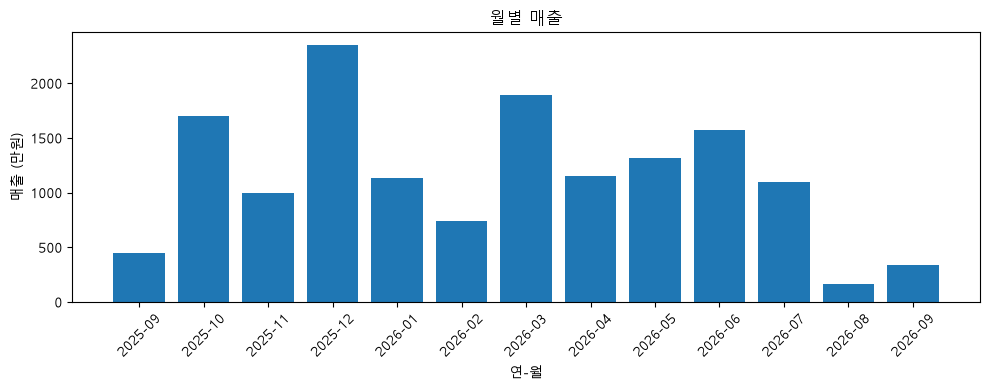

In [ ]:
import matplotlib.pyplot as plt

# 한글이 네모로 깨지지 않도록 Windows 기본 한글 글꼴을 지정한다.
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly["order_month"], monthly["revenue"] / 10000)
ax.set_title("월별 매출")
ax.set_xlabel("연-월")
ax.set_ylabel("매출 (만원)")
ax.tick_params(axis="x", rotation=45)
fig.tight_layout()

chart_path = REPORT_DIR / "monthly_revenue.png"
fig.savefig(chart_path, dpi=120)
print("그래프 저장:", chart_path)

plt.show()


## 9. 정리

이 노트북이 만든 결과물입니다.

| 경로 | 내용 |
|---|---|
| `data/processed/sales.csv` | 4개 표를 합치고 파생 컬럼을 붙인 분석용 테이블 |
| `reports/monthly_revenue.csv` | 월별 주문 건수와 매출 |
| `reports/category_revenue.csv` | 카테고리별 판매 수량과 매출 |
| `reports/top_customers.csv` | 매출 상위 고객 10명 |
| `reports/monthly_revenue.png` | 월별 매출 막대그래프 |

In [ ]:
print("=== 생성된 파일 ===")
for path in sorted(PROCESSED_DIR.glob("*")) + sorted(REPORT_DIR.glob("*")):
    size_kb = round(path.stat().st_size / 1024, 1)
    print(path.relative_to(PROJECT_ROOT), f"({size_kb} KB)")


=== 생성된 파일 ===
data\processed\sales.csv (82.8 KB)
reports\category_revenue.csv (0.2 KB)
reports\monthly_revenue.csv (0.3 KB)
reports\monthly_revenue.png (25.6 KB)
reports\top_customers.csv (0.2 KB)


## 10. 공백과 결측치 처리 실습

문자열 앞뒤에 붙은 공백을 없애고, 결측치를 채웁니다.

In [ ]:
import pandas as pd
import numpy as np

# 새로운 데이터 프레임 만들기 -> 리스트 + 딕셔너리로 표현할 수 있다
df = pd.DataFrame({
    'name': ['  홍길동  ', '이영희   ', np.nan, '박철수']
})

print("\n--- [처리전] ---")
print(df)

print(df.info())

print(df["name"].to_list())


--- [처리전] ---
      name
0    홍길동  
1   이영희   
2      NaN
3      박철수
<class 'pandas.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    3 non-null      str  
dtypes: str(1)
memory usage: 164.0 bytes
None
['  홍길동  ', '이영희   ', nan, '박철수']


In [ ]:
# 기존 공백 제거 코드 실행
# where(조건, 대체값) : 조건이 True 인 자리는 그대로 두고, False 인 자리만 대체값으로 바꾼다.
# 조건이 isna() 이므로 결측치는 NaN 그대로 두고, 나머지만 공백을 없앤 값으로 채운다.
df["name"] = df["name"].where(
    df["name"].isna(),
    df["name"].astype(str).str.strip(),
)

print("\n--- [처리중] ---")
print(df["name"].to_list())



--- [처리중] ---
['홍길동', '이영희', nan, '박철수']


In [ ]:
# 검증 코드
print("처리 결과:", df["name"].to_list())

# 결측치를 뺀 값들에 앞뒤 공백이 남아 있는지 확인한다.
filled = df["name"].dropna()
has_space = filled.str.contains(r"^\s|\s$").any()

print("앞뒤 공백이 남은 값이 있는가:", bool(has_space))
print("결측치 개수:", int(df["name"].isna().sum()))


처리 결과: ['홍길동', '이영희', nan, '박철수']
앞뒤 공백이 남은 값이 있는가: False
결측치 개수: 1


## 10-3. 결측치 채우기

`fillna()` 는 비어 있는 자리에 지정한 값을 넣습니다.

In [ ]:
# 결측치 채우기
df["name"] = df["name"].fillna("이름없음")

print("--- [처리후] ---")
print(df)
print()
print(df["name"].to_list())


--- [처리후] ---
   name
0   홍길동
1   이영희
2  이름없음
3   박철수

['홍길동', '이영희', '이름없음', '박철수']


## 10-4. `where` 는 왜 썼는가

`str.strip()` 은 결측치를 건드리지 않고 그대로 둡니다.
그래서 이 버전에서는 `strip()` 만 써도 결과가 같습니다.

`where(조건, 대체값)` 을 쓴 이유는 결측치 자리를 원본 그대로 보호한다는 의도를
코드에 드러내기 위해서입니다. pandas 버전에 따라 `astype(str)` 이 결측치를
문자열 `'nan'` 으로 바꾸는 경우가 있어, 그때도 안전하게 동작합니다.

In [ ]:
test = pd.Series(["  홍길동  ", np.nan])

print("pandas 버전:", pd.__version__)
print()
print("strip 만:            ", test.str.strip().to_list())
print("astype(str) 후 strip:", test.astype(str).str.strip().to_list())
print()
print("두 경우 모두 결측치(nan)가 유지되는 것을 확인할 수 있다.")


pandas 버전: 3.0.5

strip 만:             ['홍길동', nan]
astype(str) 후 strip: ['홍길동', nan]

두 경우 모두 결측치(nan)가 유지되는 것을 확인할 수 있다.
